# DEAP

In [1]:
import deap

In [2]:
import random

from deap import base
from deap import creator
from deap import tools

In [3]:
import numpy as np
import os
import polars as pl
import matplotlib.pyplot as plt

## Load admissions data

In [4]:
path_to_msoa_stats = os.path.join('..', 'data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [5]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [6]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [7]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [8]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [9]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [10]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [11]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [12]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [13]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [14]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [15]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [16]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [17]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [18]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Admissions prediction setup

In [64]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [71]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

Goodness check option 2: This calculates the mean absolute difference between the predicted and real admissions numbers:

In [21]:
def find_mean_abs_diff(yhat, y):
    # Difference from actual:
    absres = np.abs((yhat - y))
    # Mean of differences:
    mean_absres = absres.mean()
    return mean_absres

To check accuracy, the following function calculates R-squared:

In [161]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y = np.array(y)
    yhat = np.array(yhat)
    y_mean = np.mean(y)#.mean()
    ss_res = np.sum(((yhat - y)**2.0))#.sum()
    ss_tot = np.sum(((y - y_mean)**2.0))#.sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

## Parameter setup

Which values are allowed for each coefficient?

In [24]:
df_anneal_results = pl.read_csv(os.path.join('..', 'outputs', 'multi_optimise_coeffs_results_anneal.csv'))

Only keep results with R-squared at least 0.5:

In [25]:
df_anneal_results = df_anneal_results.filter(df_anneal_results['r2_all'] >= 0.5)

In [26]:
df_anneal_results.head()

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
79,"""requested number of basinhoppi…",true,100,0,177041,0.49557,0.5836,0.64152,0.61191,0.62633,0.59612,0.0005943,0.0030936,0.0066295,0.0068126,0.0134062,0.0005555,0.0025696,0.0029554,0.0068098,0.0134062,0.0004168,0.0024093,0.0029233,0.0055252,0.0134053,0.0003348,0.0023408,0.0028641,0.0045966,0.0133829,0.0002737,0.0023074,0.0026505,0.0033797,0.0131937
44,"""requested number of basinhoppi…",true,100,0,179357,0.49622,0.58376,0.64227,0.61291,0.62742,0.59685,0.0005903,0.0031295,0.0061421,0.0062133,0.0143481,0.0005699,0.0025356,0.0026058,0.0058422,0.0141907,0.0004522,0.0021978,0.0024619,0.0046462,0.0141867,0.0003279,0.0021325,0.0023699,0.0045319,0.0141806,0.0002409,0.002094,0.0023451,0.0036751,0.0138665
77,"""requested number of basinhoppi…",true,100,0,172091,0.49586,0.58396,0.64202,0.61332,0.62628,0.59663,0.0005927,0.0030561,0.0065211,0.0065365,0.0137685,0.000555,0.0025213,0.0031027,0.0061819,0.0137682,0.000445,0.0019151,0.0026733,0.0054802,0.0137679,0.000359,0.0018645,0.0023354,0.005173,0.0136209,0.000283,0.0018281,0.0023299,0.0043262,0.0131526
99,"""requested number of basinhoppi…",true,100,0,180651,0.49587,0.58327,0.63926,0.61057,0.62415,0.59492,0.0005944,0.0036772,0.006583,0.0065978,0.0129104,0.0005515,0.0030502,0.0031747,0.0065789,0.0129098,0.0004348,0.0025558,0.0031743,0.0057414,0.0125977,0.0003499,0.0024574,0.0029342,0.0053551,0.0124652,0.0002256,0.0024574,0.0029336,0.0049205,0.0123456
42,"""requested number of basinhoppi…",true,100,0,176698,0.49365,0.58306,0.63954,0.61056,0.62392,0.59449,0.0005737,0.0032831,0.0070498,0.0074233,0.0127927,0.0005462,0.0023667,0.003571,0.0073508,0.0127915,0.000429,0.0020305,0.0035135,0.0060709,0.0126241,0.0003377,0.0020292,0.0032674,0.0054652,0.0126232,0.0002126,0.0020291,0.0032674,0.0050893,0.0124073


In [27]:
qmin_list = sorted(dict_quantiles.keys())[:-1]

In [28]:
qmin_list

[0.0, 0.2, 0.4, 0.6, 0.8]

In [29]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

Make a copy of the best possible input coefficients:

In [109]:
best_coeffs = df_anneal_results.filter(df_anneal_results['r2_all'] == df_anneal_results['r2_all'].max())[coeff_names].to_numpy().tolist()[0]

In [30]:
def gen_attr(df_anneal_results):
    """
    Pick out a set of coefficients from the dataframe.
    """
    row_index = random.randrange(0, len(df_anneal_results), 1)
    new_coeffs = df_anneal_results[row_index, :][coeff_names].to_numpy().tolist()[0]
    new_coeffs = round_coeffs(new_coeffs)
    return tuple(new_coeffs)

In [31]:
def round_coeffs(coeffs):
    return tuple([round(c, 6) for c in coeffs])

Example generate some coeffs:

In [32]:
gen_attr(df_anneal_results)

(0.000574,
 0.003836,
 0.006025,
 0.006067,
 0.01416,
 0.000555,
 0.002587,
 0.002715,
 0.006066,
 0.014156,
 0.000447,
 0.002332,
 0.002605,
 0.004425,
 0.014156,
 0.000333,
 0.00228,
 0.002437,
 0.004208,
 0.014155,
 0.000252,
 0.002278,
 0.002349,
 0.003762,
 0.013507)

In [33]:
np.array(gen_attr(df_anneal_results)).reshape(5, 5)

array([[0.000569, 0.004607, 0.006118, 0.006295, 0.013171],
       [0.000542, 0.003341, 0.003363, 0.005812, 0.013168],
       [0.000424, 0.002412, 0.003071, 0.005716, 0.013035],
       [0.000376, 0.002002, 0.00307 , 0.004935, 0.012713],
       [0.000256, 0.002001, 0.002913, 0.004511, 0.01266 ]])

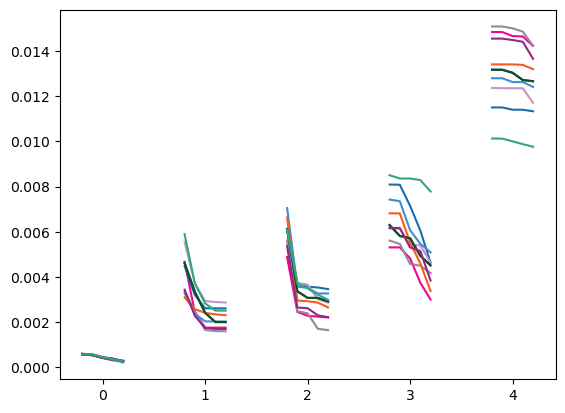

In [34]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

for i in range(10):
    colour = np.random.rand(3,)
    g = gen_attr(df_anneal_results)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(g)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour)
        offset += 0.1
plt.show()

In [35]:
def clip_coeffs(coeffs):
    # Clip coefficients to sit within allowed range.
    return np.clip(coeffs, a_min=0.0, a_max=1.0,).tolist()

In [36]:
def force_coeffs_increasing(coeffs):
    """
    Make sure each coefficient is no larger than the next.
    """
    def check_success(coeffs_grid):
        # # Check difference along each row:
        # q_ok = (np.sign(np.diff(coeffs_grid, axis=1)) >= 0).all()
        # # Check difference along each column:
        # age_ok = (np.sign(np.diff(coeffs_grid, axis=0)) >= 0).all()
        signs_age, signs_q = check_pattern(coeffs_grid)
        age_ok = (signs_age == 0).all()
        q_ok = (signs_q == 0).all()
        return (q_ok & age_ok)
    
    def check_pattern(coeffs_grid):
        # Start with a 5x5 grid:
        signs_age = np.zeros((5, 5), dtype=int)
        signs_q = np.zeros((5, 5), dtype=int)
        # Fill in all but the first row/column with diffs:
        signs_age[1:, :] = (np.sign(np.diff(coeffs_grid, axis=0)) > 0).astype(int)
        signs_q[:, :-1] = (np.sign(np.diff(coeffs_grid, axis=1)) < 0).astype(int)
        return signs_age, signs_q
    
    def sort_inds_by_farthest(inds):
        if len(inds[0]) < 2:
            # Don't bother if there's nothing to sort.
            return inds
        else:
            pass

        # Gather rows and columns into one array:
        inds_stack = np.vstack(inds)
        # Find the largest row/column:
        max_ind = np.max(inds_stack, axis=0)
        # Find the order that would sort them from largest to smallest:
        inds_sort = np.argsort(max_ind)[::-1]
        # Sort the inds:
        inds = (inds[0][inds_sort], inds[1][inds_sort])
        return inds
        
    coeffs_grid = np.array(coeffs).reshape(5, 5)
    success = check_success(coeffs_grid)

    count = 0
    while success == False:
        signs_age, signs_q = check_pattern(coeffs_grid)
        # Pick out which values don't fit the pattern.
        # Each inds tuple has an array of the row indices, inds[0],
        # and then an array of the column indices, inds[1].
        inds_to_change_age = np.where(signs_age > 0)
        inds_to_change_q = np.where(signs_q > 0)
        inds_to_change_both = np.where((signs_q > 0) & (signs_age > 0))
        # Order the inds, farthest row/column first:
        inds_to_change_age = sort_inds_by_farthest(inds_to_change_age)
        inds_to_change_q = sort_inds_by_farthest(inds_to_change_q)
        inds_to_change_both = sort_inds_by_farthest(inds_to_change_both)

        # Nudge the values, starting from the far edges.
        if len(inds_to_change_both[0]) > 0:
            # Set the breaking value to whichever is smaller of its
            # adjacent coefficients.
            ind_row = inds_to_change_both[0][0]
            ind_col = inds_to_change_both[1][0]
            # Pick out the next values along:
            next_age = coeffs_grid[ind_row - 1, ind_col]
            next_q = coeffs_grid[ind_row, ind_col + 1]
            # Find the smaller one:
            new_val = np.min([next_q, next_age])
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val
        elif len(inds_to_change_age[0]) > 0:
            # Set the breaking value to the next age up.
            ind_row = inds_to_change_age[0][0]
            ind_col = inds_to_change_age[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row - 1, ind_col]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val
        else:
            # Set the breaking value to the next q up.
            ind_row = inds_to_change_q[0][0]
            ind_col = inds_to_change_q[1][0]
            # Pick out the next value along:
            new_val = coeffs_grid[ind_row, ind_col + 1]
            # Update the coefficient:
            coeffs_grid[ind_row, ind_col] = new_val

        success = check_success(coeffs_grid)
        count += 1
        if count > 100:
            # Give up.
            success = True
    
    return coeffs_grid.flatten().tolist()

Check the force-increasing function:

In [37]:
coeffs = np.arange(25).reshape(5, 5)[::-1].flatten()
coeffs[21] += 12

print(np.array(coeffs).reshape(5, 5))

np.array(force_coeffs_increasing(coeffs)).reshape(5, 5)

[[20 21 22 23 24]
 [15 16 17 18 19]
 [10 11 12 13 14]
 [ 5  6  7  8  9]
 [ 0 13  2  3  4]]


array([[20, 21, 22, 23, 24],
       [15, 16, 17, 18, 19],
       [10, 11, 12, 13, 14],
       [ 5,  6,  7,  8,  9],
       [ 0,  2,  2,  3,  4]])

## Set up algorithm


In [38]:
creator.create("FitnessMax", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [39]:
toolbox = base.Toolbox()

# Attribute generator 
#                      define 'attr_bool' to be an attribute ('gene')
#                      which corresponds to integers sampled uniformly
#                      from the range [0,1] (i.e. 0 or 1 with equal
#                      probability)
# toolbox.register("attr_unif", random.uniform, 0, 1)

# Structure initializers
#                         define 'individual' to be an individual
#                         consisting of 100 'attr_bool' elements ('genes')
# toolbox.register("individual", tools.initIterate, creator.Individual, gen_attr, start_ranges_by_coeff)


In [59]:
# the goal ('fitness') function to be maximized
def eval_admissions(admissions_lists, x_lists, individual):

    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5]
        yhat = predict_admissions(x_lists_here, coeffs)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Use only one of the following options for checking the fit:
    sum_sqres = find_square_residuals(predicted_all, observed_all)
    # sum_sqres = find_mean_abs_diff(yhat, admissions)
    return sum_sqres,

In [41]:
mutate_means_by_coeff = np.round(df_anneal_results[coeff_names].mean().to_numpy()[0], 7).tolist()
mutate_stds_by_coeff = np.round(df_anneal_results[coeff_names].std().to_numpy()[0], 7).tolist()

In [42]:
mutate_stds_by_coeff

[1.56e-05,
 0.0008627,
 0.0007634,
 0.0008543,
 0.001089,
 2.06e-05,
 0.0004852,
 0.0004493,
 0.0007026,
 0.0010658,
 1.64e-05,
 0.0004825,
 0.0004324,
 0.0008506,
 0.0011136,
 2.56e-05,
 0.0004873,
 0.000478,
 0.0009202,
 0.0011512,
 2.7e-05,
 0.0004699,
 0.0004674,
 0.0010332,
 0.0010352]

In [43]:
def mutate_coeffs(mutate_means_by_coeff, mutate_stds_by_coeff, individual, indpb=0.05):
    mutated = []
    for i, m in enumerate(mutate_means_by_coeff):
        current_val = individual[i]
        s = mutate_stds_by_coeff[i]
        if random.random() < indpb:
            # Mutate
            offset = random.gauss(m, s) - m
            mutated.append(current_val + offset)
        else:
            # Keep current value
            mutated.append(current_val)
    return mutated

In [44]:
for i in range(3):
    g = gen_attr(df_anneal_results)
    m = mutate_coeffs(mutate_means_by_coeff, mutate_stds_by_coeff, g, indpb=0.20)
    print(g)
    print(m)
    print('')

(0.00059, 0.003129, 0.006142, 0.006213, 0.014348, 0.00057, 0.002536, 0.002606, 0.005842, 0.014191, 0.000452, 0.002198, 0.002462, 0.004646, 0.014187, 0.000328, 0.002132, 0.00237, 0.004532, 0.014181, 0.000241, 0.002094, 0.002345, 0.003675, 0.013867)
[0.00059, 0.0033592150252538394, 0.00730153434616319, 0.006213, 0.014348, 0.00057, 0.002536, 0.002606, 0.005842, 0.014191, 0.000452, 0.002198, 0.002462, 0.004646, 0.014724631400612323, 0.000328, 0.002132, 0.00237, 0.0041774947708824416, 0.015328507860603026, 0.000241, 0.002094, 0.002345, 0.003675, 0.014146140953548223]

(0.000607, 0.002278, 0.006992, 0.006995, 0.013494, 0.000568, 0.002109, 0.002965, 0.006995, 0.013494, 0.00043, 0.001843, 0.002216, 0.004205, 0.015431, 0.000362, 0.001702, 0.001982, 0.003835, 0.015041, 0.000264, 0.001702, 0.001976, 0.002769, 0.014895)
[0.0006193871939633602, 0.002278, 0.006992, 0.006995, 0.013494, 0.000568, 0.002109, 0.002965, 0.006995, 0.013494, 0.00043, 0.001843, 0.002592658964772969, 0.004205, 0.015431, 0.000

In [45]:
#----------
# Operator registration
#----------


toolbox.register("gen_attr", gen_attr, df_anneal_results)

toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.gen_attr)

# define the population to be a list of individuals
# but don't specify how many here.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# register the crossover operator
# toolbox.register("mate", tools.cxUniform, indpb=0.4)
toolbox.register("mate", tools.cxTwoPoint)

# register a mutation operator with a probability to
# flip each attribute/gene of 0.05
# toolbox.register("mutate", tools.mutGaussian, mu=1e-4, sigma=1e-3, indpb=0.05)
toolbox.register('mutate', mutate_coeffs, mutate_means_by_coeff, mutate_stds_by_coeff, indpb=0.20)

# operator for selecting individuals for breeding the next
# generation: each individual of the current generation
# is replaced by the 'fittest' (best) of three individuals
# drawn randomly from the current generation.
toolbox.register("select", tools.selTournament, tournsize=3)

#----------

toolbox.register("clip", clip_coeffs)
toolbox.register("round", round_coeffs)
toolbox.register("force_increasing", force_coeffs_increasing)

Example starting population:

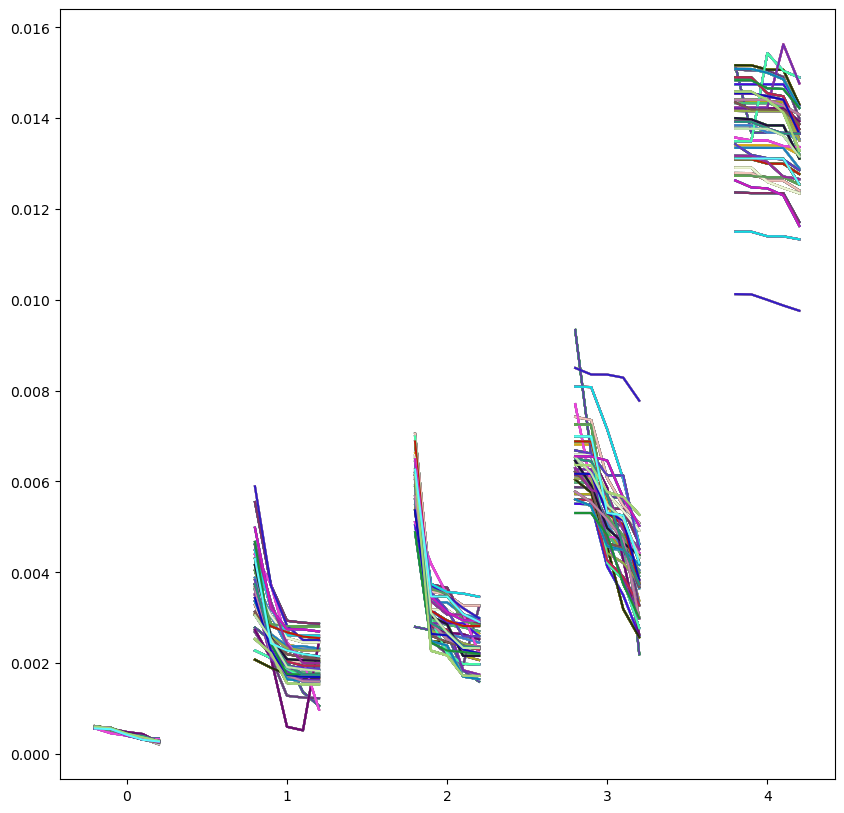

In [103]:
np.random.seed(424242)
pop = toolbox.population(n=500)

fig, ax = plt.subplots(figsize=(10, 10))

for i, individual in enumerate(pop):
    colour = np.random.rand(3,)
    # g = gen_attr(df_anneal_results)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(individual)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour)
        offset += 0.1
plt.show()

## Run

Run for each IMD band separately.

In [141]:
def main(seed):
    random.seed(seed)

    # create an initial population of 300 individuals (where
    # each individual is a list of integers)
    pop = toolbox.population(n=500)

    # CXPB  is the probability with which two individuals
    #       are crossed
    #
    # MUTPB is the probability for mutating an individual
    CXPB = 0.8
    MUTPB = 0.2

    # Keep a copy of the printed text:
    log = ''
    log += "Start of evolution\n"

    # Evaluate the entire population
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    log += f"  Evaluated {len(pop)} individuals\n"

    # Extracting all the fitnesses of 
    fits = [ind.fitness.values[0] for ind in pop]

    # Keep a copy of the best individual in each generation:
    best_inds = []
    
    # Variable keeping track of the number of generations
    g = 0

    # Begin the evolution
    while g < 25:
        # A new generation
        g = g + 1
        log += f'-- Generation {g} --\n'

        # Select the next generation individuals
        offspring = toolbox.select(pop, len(pop))
        # Clone the selected individuals
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation on the offspring
        for child1, child2 in zip(offspring[::2], offspring[1::2]):

            # cross two individuals with probability CXPB
            if random.random() < CXPB:
                toolbox.mate(child1, child2)

                # fitness values of the children
                # must be recalculated later
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:

            # mutate an individual with probability MUTPB
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        
        # Clip values to fit within parameter bounds.
        for ind in invalid_ind:
            ind[:] = toolbox.clip(ind)
        # Round values.
        for ind in invalid_ind:
            ind[:] = toolbox.round(ind)
        # Force coefficients to increase with age band.
        for ind in invalid_ind:
            ind[:] = toolbox.force_increasing(ind)
        
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        log += f"  Evaluated {len(invalid_ind)} individuals\n"

        # The population is entirely replaced by the offspring
        pop[:] = offspring

        # Gather all the fitnesses in one list and print the stats
        fits = [ind.fitness.values[0] for ind in pop]

        length = len(pop)
        mean = sum(fits) / length
        sum2 = sum(x*x for x in fits)
        std = abs(sum2 / length - mean**2)**0.5

        log += f'  Min {min(fits):9.5f}\n'
        log += f'  Max {max(fits):9.5f}\n'
        log += f'  Avg {mean:9.5f}\n'
        log += f'  Std {std:9.5f}\n'
            
        best_ind = tools.selBest(pop, 1)[0]
        best_ind_str = ', '.join([f'{b:9.7f}' for b in best_ind])
        b = best_ind.fitness.values[0]
        log += f'Best individual is ({best_ind_str}), {b:.5f}\n'

        best_inds.append(best_ind)

    log += "-- End of (successful) evolution --\n"


    return pop, best_inds, log

Evaluate over all q bands at once.

In [142]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

# For this deprivation quantile, need to pass these admissions
# into the evaluation function:
# register the goal / fitness function
toolbox.register("evaluate", eval_admissions, admissions_lists, x_lists)

In [151]:
pop_results, best_inds, log = main(seed=42)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



[[12.934754409, 15.7937479185, 12.72713827, 14.176606321199998, 13.102223784300001, 14.915372283899998, 10.6907721868, 14.0238991035, 15.2426517768, 10.6115923584, 12.563133712800001, 10.840302165, 11.8154547609, 14.7670707305, 9.245022293000002, 11.1426573685, 10.3611632364, 12.522578331600002, 9.0967438791, 6.2838008096, 10.125551758, 9.8479649576, 10.465061684399998, 10.2999181792, 7.526872580600001, 6.0941579566, 12.1842557172, 9.2109453249, 7.797864614, 10.316055759600001, 12.105685441199999, 15.2337394678, 9.3966015066, 11.030353681400001, 16.4890422795, 9.982585359000002, 9.6537709543, 20.849102782800003, 20.170480633600004, 9.271567344000001, 11.426754882400001, 12.994662773999998, 11.5287171345, 13.2407975447, 12.1688682236, 13.8976449084, 11.15758336, 15.8414426852, 10.476287087100001, 13.402139771999998, 11.31779067, 13.497809574800002, 9.4081625015, 7.3986782495, 11.759729490600002, 9.621231109, 15.256768078999999, 13.205589532800001, 11.4712559198, 9.807063001200001, 9.075

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [144]:
print(log)

Start of evolution
  Evaluated 500 individuals
-- Generation 1 --
  Evaluated 422 individuals
  Min 236.17759
  Max 248.15531
  Avg 237.33705
  Std   1.73396
Best individual is (0.0005890, 0.0033600, 0.0056080, 0.0056080, 0.0150840, 0.0005470, 0.0024850, 0.0024850, 0.0054590, 0.0150830, 0.0004420, 0.0016480, 0.0022760, 0.0048230, 0.0150010, 0.0003680, 0.0016020, 0.0017030, 0.0044960, 0.0148580, 0.0002730, 0.0015920, 0.0016470, 0.0041670, 0.0142300), 236.17759
-- Generation 2 --
  Evaluated 432 individuals
  Min 236.17759
  Max 244.80372
  Avg 236.88782
  Std   1.14535
Best individual is (0.0005890, 0.0033600, 0.0056080, 0.0056080, 0.0150840, 0.0005470, 0.0024850, 0.0024850, 0.0054590, 0.0150830, 0.0004420, 0.0016480, 0.0022760, 0.0048230, 0.0150010, 0.0003680, 0.0016020, 0.0017030, 0.0044960, 0.0148580, 0.0002730, 0.0015920, 0.0016470, 0.0041670, 0.0142300), 236.17759
-- Generation 3 --
  Evaluated 412 individuals
  Min 236.16454
  Max 243.66325
  Avg 236.62672
  Std   0.75545
Best ind

In [152]:
best_unique, best_unique_inds = np.unique(np.array(best_inds), axis=0, return_index=True)

inds_to_sort = np.argsort(best_unique_inds)
best_unique_inds = best_unique_inds[inds_to_sort]
best_unique = np.array(best_inds)[best_unique_inds]

In [153]:
best_unique

array([[0.000589, 0.00336 , 0.005508, 0.005508, 0.015084, 0.000547,
        0.002485, 0.002485, 0.005459, 0.015083, 0.000442, 0.001648,
        0.002388, 0.004574, 0.015001, 0.000368, 0.001602, 0.001703,
        0.004496, 0.014858, 0.000273, 0.001592, 0.001647, 0.004167,
        0.01423 ],
       [0.000589, 0.00336 , 0.005608, 0.005608, 0.015084, 0.000547,
        0.002485, 0.002485, 0.005459, 0.015083, 0.000426, 0.001753,
        0.002467, 0.004561, 0.015069, 0.000364, 0.001672, 0.002422,
        0.003191, 0.015065, 0.000298, 0.00166 , 0.002358, 0.002568,
        0.014299],
       [0.000589, 0.00336 , 0.005598, 0.005608, 0.015084, 0.000547,
        0.002485, 0.002485, 0.005459, 0.015083, 0.000442, 0.001648,
        0.002388, 0.004574, 0.015001, 0.000368, 0.001602, 0.001703,
        0.004496, 0.014858, 0.000273, 0.001592, 0.001647, 0.004167,
        0.01423 ],
       [0.000589, 0.00336 , 0.005608, 0.005608, 0.015084, 0.000547,
        0.002485, 0.002485, 0.005459, 0.015084, 0.000426, 0

Plot best coeffs across generations:

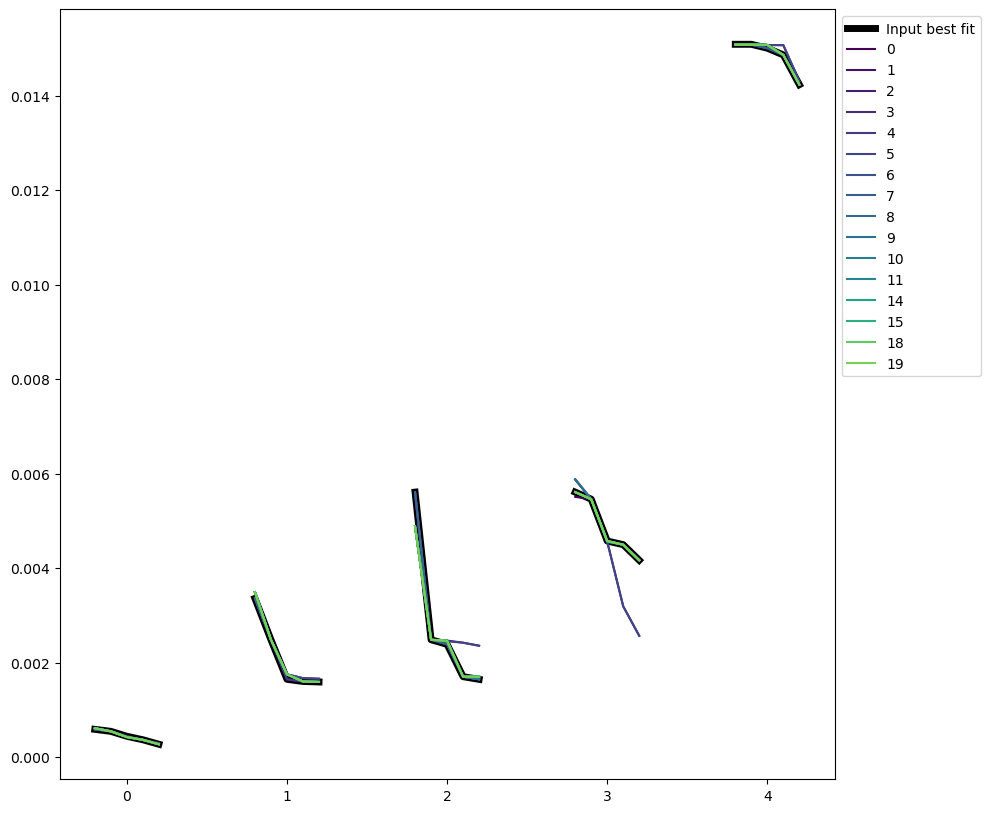

In [154]:
colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(best_inds)))

fig, ax = plt.subplots(figsize=(10, 10))


offset = -0.2
for c in range(5):
    xs = np.arange(-0.2, 0.3, 0.1) + c
    ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
    ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
    offset += 0.1
    
for i, best in enumerate(best_unique):
    ind = best_unique_inds[i]

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(best)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colours[ind], zorder=1, label=(f'{ind}' if c==0 else None))
        offset += 0.1

ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

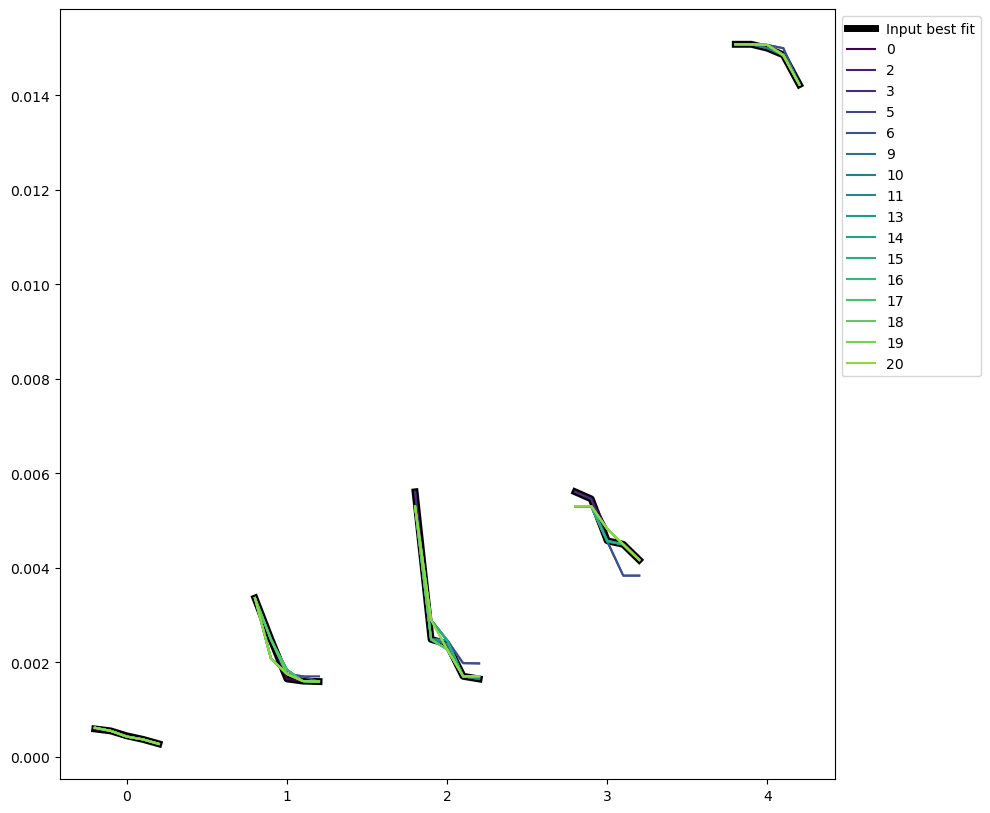

In [147]:
colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(best_inds)))

fig, ax = plt.subplots(figsize=(10, 10))


offset = -0.2
for c in range(5):
    xs = np.arange(-0.2, 0.3, 0.1) + c
    ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
    ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
    offset += 0.1
    
for i, best in enumerate(best_unique):
    ind = best_unique_inds[i]

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(best)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colours[ind], zorder=1, label=(f'{ind}' if c==0 else None))
        offset += 0.1

ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

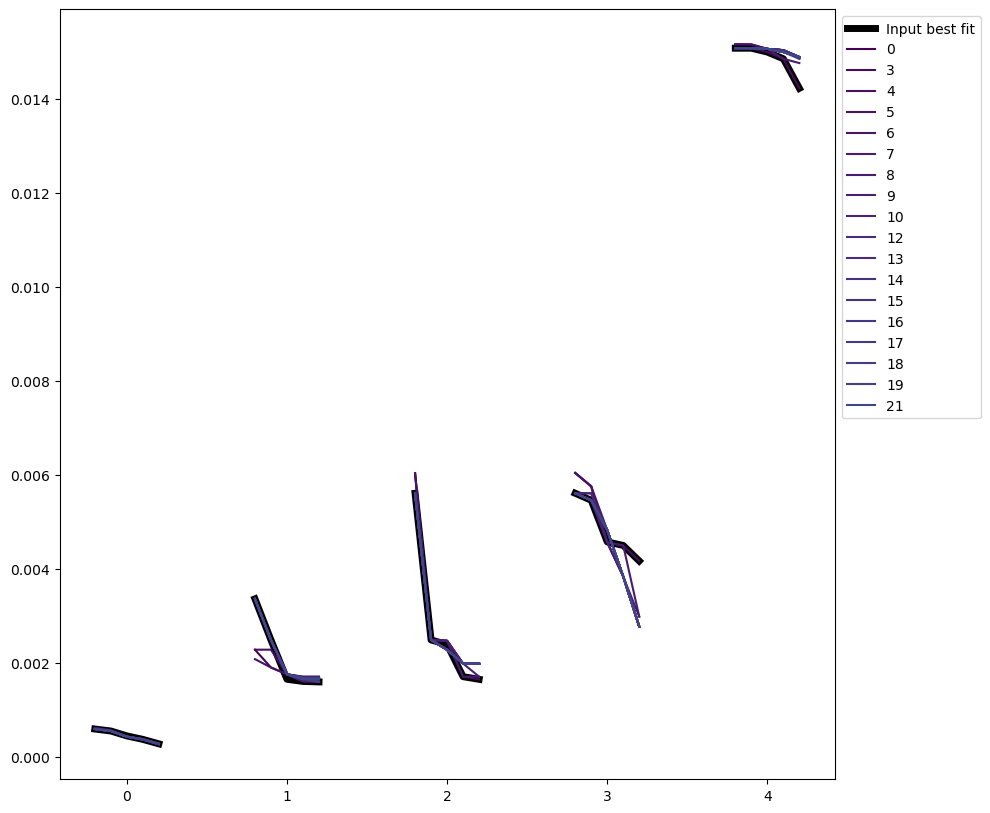

In [134]:
colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(best_inds)))

fig, ax = plt.subplots(figsize=(10, 10))


offset = -0.2
for c in range(5):
    xs = np.arange(-0.2, 0.3, 0.1) + c
    ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
    ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
    offset += 0.1
    
for i, best in enumerate(best_unique):
    ind = best_unique_inds[i]

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(best)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colours[ind], zorder=1, label=(f'{ind}' if c==0 else None))
        offset += 0.1

ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

Plot final generation population:

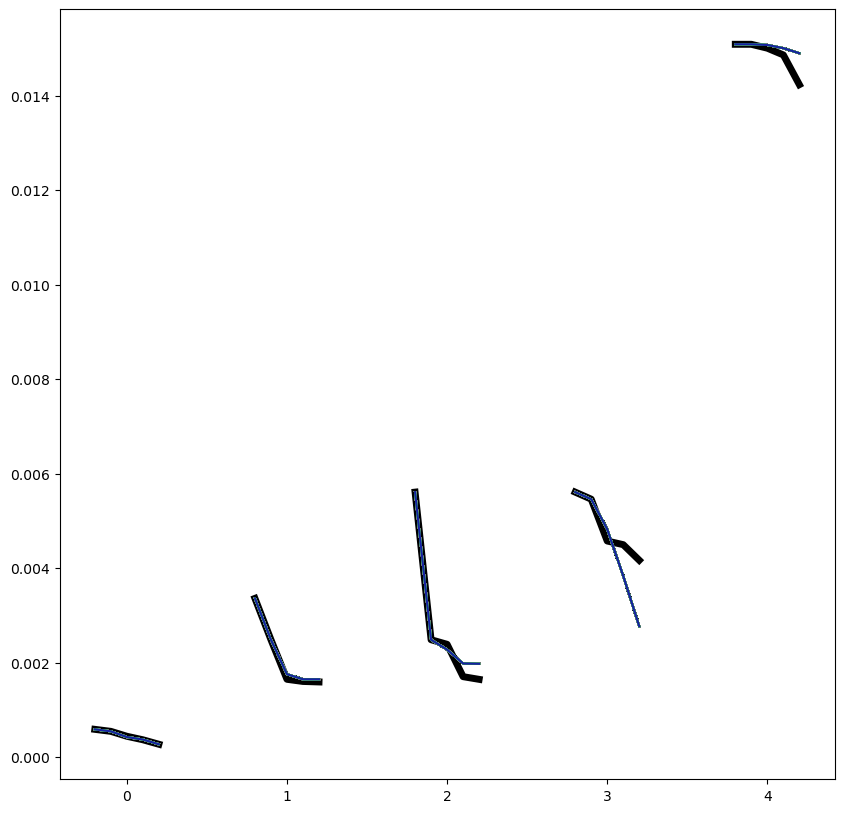

In [135]:
import matplotlib.pyplot as plt

# np.random.seed(424242)
# pop = toolbox.population(n=500)

fig, ax = plt.subplots(figsize=(10, 10))

offset = -0.2
for c in range(5):
    xs = np.arange(-0.2, 0.3, 0.1) + c
    ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
    ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
    offset += 0.1
    
for i, individual in enumerate(pop_results):
    colour = np.random.rand(3,)
    # g = gen_attr(df_anneal_results)

    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(individual)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour, zorder=1, label=(f'{ind}' if c==0 else None))
        offset += 0.1


plt.show()

In [155]:
best_inds_42 = best_inds[-1]

best_inds_42

[0.000613,
 0.003491,
 0.004881,
 0.005608,
 0.015075,
 0.000547,
 0.002485,
 0.002485,
 0.005459,
 0.015075,
 0.000426,
 0.001753,
 0.002467,
 0.004574,
 0.015069,
 0.000368,
 0.001602,
 0.001703,
 0.004496,
 0.014858,
 0.000273,
 0.001592,
 0.001703,
 0.004167,
 0.01423]

In [148]:
best_inds_4242 = best_inds[-1]

best_inds_4242

[0.000614,
 0.00336,
 0.005306,
 0.005306,
 0.015084,
 0.000547,
 0.002077,
 0.002894,
 0.005306,
 0.015084,
 0.000426,
 0.001753,
 0.002276,
 0.004823,
 0.015069,
 0.000368,
 0.001602,
 0.001703,
 0.004496,
 0.014858,
 0.000273,
 0.001592,
 0.001703,
 0.004167,
 0.01423]

In [139]:
best_inds_424242 = best_inds[-1]

best_inds_424242

[0.000589,
 0.00336,
 0.005608,
 0.005608,
 0.015084,
 0.000547,
 0.002485,
 0.002485,
 0.005459,
 0.015084,
 0.000426,
 0.001755,
 0.002276,
 0.004823,
 0.015069,
 0.000374,
 0.001648,
 0.001982,
 0.003835,
 0.015001,
 0.000273,
 0.001648,
 0.001976,
 0.002769,
 0.014895]

In [140]:
best_coeffs

[0.0005891,
 0.0033597,
 0.0056079,
 0.0056082,
 0.0150836,
 0.0005466,
 0.002485,
 0.0024852,
 0.0054589,
 0.0150835,
 0.0004424,
 0.0016477,
 0.002388,
 0.0045738,
 0.0150011,
 0.0003684,
 0.0016023,
 0.0017035,
 0.0044965,
 0.0148584,
 0.0002734,
 0.0015917,
 0.0016467,
 0.0041668,
 0.0142296]

In [165]:
for coeffs in [best_inds_424242, best_inds_4242, best_inds_42]:
    print(np.array(coeffs).reshape(5, 5))
    print('\n'*2)

[[0.000589 0.00336  0.005608 0.005608 0.015084]
 [0.000547 0.002485 0.002485 0.005459 0.015084]
 [0.000426 0.001755 0.002276 0.004823 0.015069]
 [0.000374 0.001648 0.001982 0.003835 0.015001]
 [0.000273 0.001648 0.001976 0.002769 0.014895]]



[[0.000614 0.00336  0.005306 0.005306 0.015084]
 [0.000547 0.002077 0.002894 0.005306 0.015084]
 [0.000426 0.001753 0.002276 0.004823 0.015069]
 [0.000368 0.001602 0.001703 0.004496 0.014858]
 [0.000273 0.001592 0.001703 0.004167 0.01423 ]]



[[0.000613 0.003491 0.004881 0.005608 0.015075]
 [0.000547 0.002485 0.002485 0.005459 0.015075]
 [0.000426 0.001753 0.002467 0.004574 0.015069]
 [0.000368 0.001602 0.001703 0.004496 0.014858]
 [0.000273 0.001592 0.001703 0.004167 0.01423 ]]





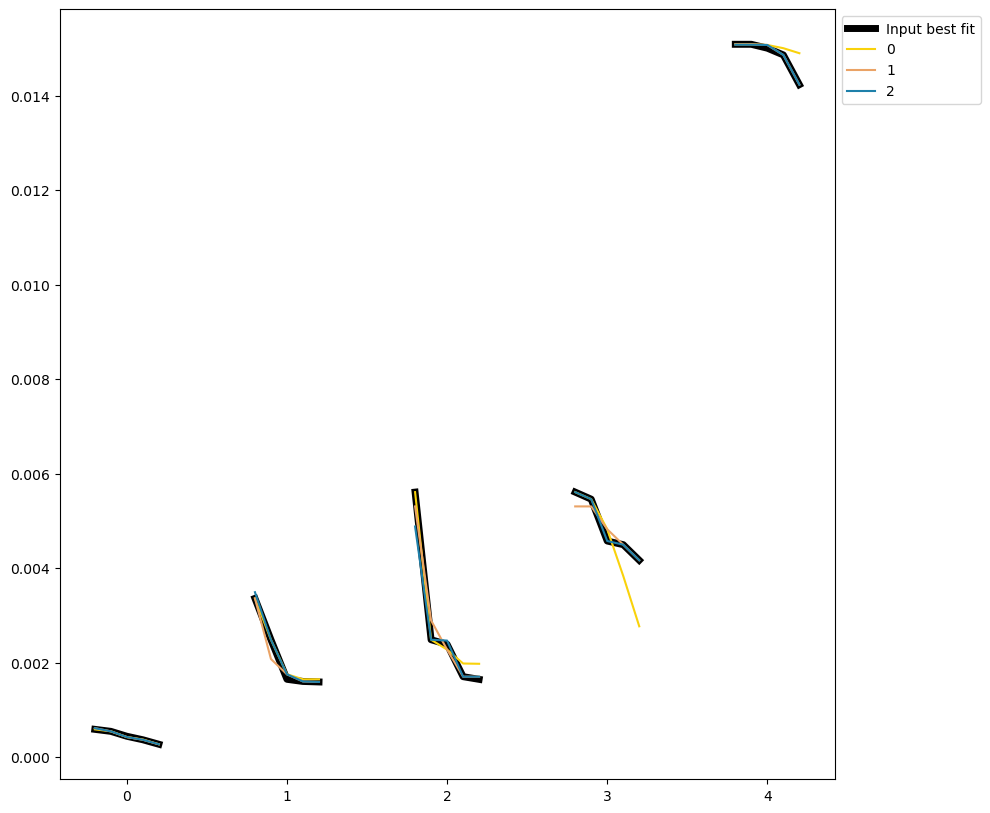

In [157]:
# colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(best_inds)))

fig, ax = plt.subplots(figsize=(10, 10))


offset = -0.2
for c in range(5):
    xs = np.arange(-0.2, 0.3, 0.1) + c
    ys = np.array(best_coeffs)[np.arange(0, 25, 5) + c]
    ax.plot(xs, ys, color='k', zorder=0, linewidth=5, label=('Input best fit' if c==0 else None))
    offset += 0.1
    
for i, best in enumerate([best_inds_424242, best_inds_4242, best_inds_42]):
    # ind = best_unique_inds[i]

    colour = np.random.rand(3, )  # colours[i]
    offset = -0.2
    for c in range(5):
        # xs = np.arange(5) + offset
        # ys = g[c*5:(c*5)+5]
        xs = np.arange(-0.2, 0.3, 0.1) + c
        
        ys = np.array(best)[np.arange(0, 25, 5) + c]
        ax.plot(xs, ys, color=colour, zorder=1, label=(f'{i}' if c==0 else None))
        offset += 0.1

ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

plt.show()

In [163]:
for coeffs in [best_coeffs, best_inds_424242, best_inds_4242, best_inds_42]:
    predictions_lists = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        c = coeffs[(i*5):(i*5)+5]
        yhat = predict_admissions(x_lists_here, c)
        predictions_lists.append(yhat)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Calculate r-squared:
    r2 = calculate_rsquared(observed_all, predicted_all)
    print(r2)

0.5978261067957678
0.5980566389695967
0.5980795116957636
0.5980614149956701
